# 加利福尼亚房价回归案例_神经网络

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

# 1. 加载加利福尼亚房价数据集
california = fetch_california_housing(data_home='./data')
X = california.data
y = california.target

print("原始特征形状:", X.shape)
print("目标形状:", y.shape)

# 2. 划分 train:val:test = 0.6 : 0.2 : 0.2
# 先划分出 train+val 和 test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 再从 train+val 中划分出 val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print("训练集:", X_train.shape)
print("验证集:", X_val.shape)
print("测试集:", X_test.shape)

# 3. 标准化（只用训练集数据拟合）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. 定义自定义 Dataset 类（内部统一转成 float32 tensor）
class CaliforniaHousingDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features.astype(np.float32))
        self.y = torch.tensor(targets.astype(np.float32)).unsqueeze(1)  # 调整为[N, 1]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# 5. 创建 Dataset 实例
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 6. 创建 DataLoader
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 训练集 shuffle
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # 验证集不 shuffle
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  # 测试集不 shuffle

# 简单取一个 batch 看看形状
for X_batch, y_batch in train_loader:
    print("一个 batch 的特征形状:", X_batch.shape)
    print("一个 batch 的标签形状:", y_batch.shape)
    break


原始特征形状: (20640, 8)
目标形状: (20640,)
训练集: (12384, 8)
验证集: (4128, 8)
测试集: (4128, 8)
一个 batch 的特征形状: torch.Size([64, 8])
一个 batch 的标签形状: torch.Size([64, 1])


In [2]:
import torch.nn as nn

# 定义一个包含一层30个神经元的隐藏层和输出层的神经网络
class SimpleRegressor(nn.Module):
    def __init__(self, input_dim):
        """
        初始化模型

        Args:
            input_dim: 输入特征的维度
        """

        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        """
        前向传播

        Args:
            x: 输入特征
        """
        return self.model(x)

In [3]:
# 做一次前向计算进行模型验证

# 假设已定义好 input_dim
input_dim = X_train.shape[1]
model = SimpleRegressor(input_dim)

# 取一个 batch 进行前向传播
model.eval()  # 切换到评估模式
with torch.no_grad():  # 不计算梯度
    X_batch, y_batch = next(iter(val_loader))  # 获取一个 batch
    outputs = model(X_batch)
    print("模型输出形状:", outputs.shape)
    print("真实值形状:", y_batch.shape)

模型输出形状: torch.Size([64, 1])
真实值形状: torch.Size([64, 1])


模型参数总数: 301
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing)

开始训练模型

开始训练模型（回归任务）
训练轮数: 100
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
设备: cuda
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing)

Epoch [1/100], Train Loss: 2.0759, Val Loss: 0.9994
Epoch [2/100], Train Loss: 0.6739, Val Loss: 0.6920
Epo

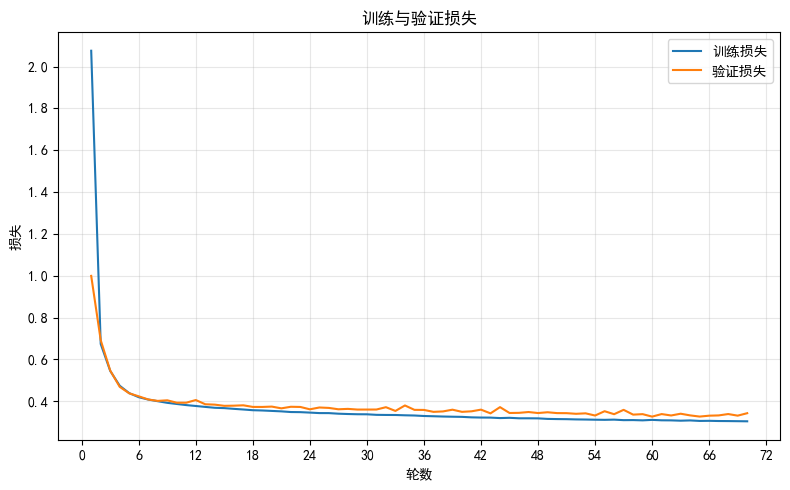

训练历史曲线绘制完成！

训练和评估完成！
最终验证损失: 0.3428
最终测试损失: 0.3314


In [5]:
# 使用 Train_v4.py 中的 Trainer 类进行模型训练和评估

from Train_v4 import Trainer
import torch.nn as nn
import torch.optim as optim

# 1. 创建模型实例
input_dim = X_train.shape[1]  # 8
model = SimpleRegressor(input_dim)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数总数: {total_params:,}")

# 2. 创建损失函数（MSE）和优化器（Adam）
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 使用 Adam 优化器，学习率 0.001

# 3. 创建 Trainer 实例
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    early_stopping=True,  # 启用早停
    patience=10,  # 连续10个epoch没有改善则停止
    monitor='val_loss',  # 监控验证损失
    min_delta=0.001,  # 最小改善幅度
    restore_best_weights=True,  # 恢复最佳模型权重
    save_best_model=True,  # 保存最佳模型
    save_every_epoch=False,  # 不每个epoch都保存
    save_dir='./checkpoints/california_housing',  # 模型保存目录
    model_name='california_housing_regression'  # 模型名称
)

# 4. 训练模型
print("\n" + "=" * 60)
print("开始训练模型")
print("=" * 60)
num_epochs = 100  # 设置最大训练轮数
trainer.train_regression(num_epochs=num_epochs)

# 5. 评估模型（验证集）
print("\n" + "=" * 60)
print("评估模型 - 验证集")
print("=" * 60)
val_loss = trainer.evaluating_regression(val_loader, verbose=True)

# 6. 评估模型（测试集）
print("\n" + "=" * 60)
print("评估模型 - 测试集")
print("=" * 60)
test_loss = trainer.evaluating_regression(test_loader, verbose=True)

# 7. 绘制训练历史曲线（只绘制损失，不绘制准确率）
print("\n" + "=" * 60)
print("绘制训练历史曲线")
print("=" * 60)
trainer.plot_history(plot_loss=True, plot_acc=False)

print("\n" + "=" * 60)
print("训练和评估完成！")
print("=" * 60)
print(f"最终验证损失: {val_loss:.4f}")
print(f"最终测试损失: {test_loss:.4f}")
print("=" * 60)
